<a href="https://colab.research.google.com/github/afuchs0/RatingSystem/blob/master/BusinessAnalytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'startup-investments' dataset.
Loading CSV files...
Processing companies & demographics...
Establishing Series A cutoffs...
Time-boxing and engineering features...


/tmp/ipykernel_926/2180929158.py:100: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  valid_rels['title_lower'].str.contains(r'\b(ceo|cto|coo|cfo|cio|cso|cmo|cro)\b|chief|president', regex=True, na=False),
/tmp/ipykernel_926/2180929158.py:102: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  valid_rels['title_lower'].str.contains(r'\b(vp|svp|evp)\b|vice president|director|head|manager', regex=True, na=False)


Engineering education features...
Building final dataset...
Total companies: 196553
Bootstrapped: 184691
Funded: 11862


/tmp/ipykernel_926/2180929158.py:270: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='is_funded', y='success', data=final_df, palette='viridis')
/tmp/ipykernel_926/2180929158.py:275: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rounds_count', y='success', data=final_df, palette='magma')
/tmp/ipykernel_926/2180929158.py:280: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='founder_bins', y='success', data=final_df, palette='coolwarm')


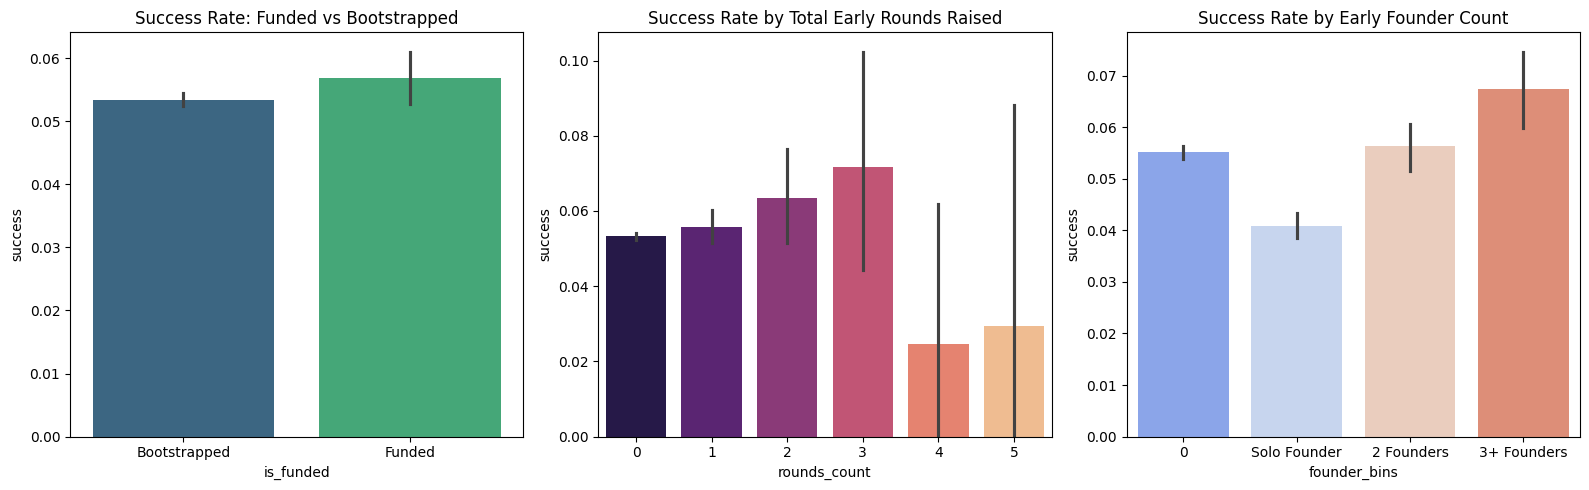


--- Companies with at least 2 funding rounds ---
Found 1888 companies that reached at least round 2.

                       name category_code country_code  success  pre_series_a_team_size  pre_series_a_founders  pre_series_a_clevel  pre_series_a_board  pre_series_a_vps  pre_series_a_employees  pre_series_a_milestones  pre_series_a_product_launches  pre_series_a_partnerships  pre_series_a_user_metrics  pre_series_a_awards  avg_founder_edu_score  has_top_uni_founder  founder_stem_ratio    round_1 duration_1 round_name_1    round_2 duration_2 round_name_2    round_3 duration_3 round_name_3 round_4 duration_4 round_name_4 round_5 duration_5 round_name_5
41                    Wevod   games_video          FRA        0                     2.0                    0.0                  1.0                 0.0               0.0                     1.0                      0.0                            0.0                        0.0                        0.0                  0.0               

In [ ]:
#This is the most advanced common cell
!pip install -q kagglehub
import pandas as pd
import numpy as np
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Download and Load Dataset
# ==========================================
print("Downloading dataset...")
path = kagglehub.dataset_download("justinas/startup-investments")

print("Loading CSV files...")
df_objects = pd.read_csv(os.path.join(path, "objects.csv"), low_memory=False)
df_rounds = pd.read_csv(os.path.join(path, "funding_rounds.csv"), low_memory=False)
df_relationships = pd.read_csv(os.path.join(path, "relationships.csv"), low_memory=False)
df_milestones = pd.read_csv(os.path.join(path, "milestones.csv"), low_memory=False)
df_degrees = pd.read_csv(os.path.join(path, "degrees.csv"), low_memory=False)
df_people = pd.read_csv(os.path.join(path, "people.csv"), low_memory=False)


# ==========================================
# 2. Base Companies & Target Variable
# ==========================================
print("Processing companies & demographics...")
df_companies = df_objects[df_objects['entity_type'] == 'Company'].copy()

df_companies = df_companies[['id', 'name', 'status', 'category_code', 'country_code', 'founded_at']]
df_companies['success'] = df_companies['status'].isin(['ipo', 'acquired']).astype(int)
df_companies['founded_at'] = pd.to_datetime(df_companies['founded_at'], errors='coerce')

# ==========================================
# 3. Filtering Logic & Cutoff Dates
# ==========================================
print("Establishing Series A cutoffs...")
df_rounds['funded_at'] = pd.to_datetime(df_rounds['funded_at'], errors='coerce')
df_rounds = df_rounds.dropna(subset=['funded_at'])

exclude_codes = ['debt_round', 'grant', 'post_ipo_debt', 'post_ipo_equity', 'secondary_market', 'partial']
df_rounds = df_rounds[~df_rounds['funding_round_code'].isin(exclude_codes)]

cutoff_codes = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'private_equity']
cutoff_types = ['series-a', 'series-b', 'series-c+', 'venture', 'private-equity', 'post-ipo']

is_series_a_or_later = (
    df_rounds['funding_round_code'].isin(cutoff_codes) |
    (df_rounds['funding_round_type'].isin(cutoff_types) & ~df_rounds['funding_round_code'].isin(['seed', 'angel']))
)

cutoff_dates = df_rounds[is_series_a_or_later].groupby('object_id')['funded_at'].min().reset_index()
cutoff_dates.rename(columns={'funded_at': 'cutoff_date'}, inplace=True)

df_companies = df_companies.merge(cutoff_dates, left_on='id', right_on='object_id', how='left').drop(columns=['object_id'])
df_rounds = df_rounds.merge(cutoff_dates, on='object_id', how='left')

valid_early_codes = ['seed', 'angel', 'convertible', 'crowd', 'crowd_equity']
valid_early_types = ['angel', 'crowdfunding']

early_rounds = df_rounds[
    (df_rounds['funded_at'] < df_rounds['cutoff_date']) |
    (df_rounds['cutoff_date'].isna() & (
        df_rounds['funding_round_code'].isin(valid_early_codes) |
        df_rounds['funding_round_type'].isin(valid_early_types)
    ))
].copy()

# ==========================================
# 4. Sequence & Durations
# ==========================================
early_rounds['raised_amount_usd'] = pd.to_numeric(early_rounds['raised_amount_usd'], errors='coerce')
early_rounds = early_rounds.sort_values(by=['object_id', 'funded_at'])
early_rounds['round_number'] = early_rounds.groupby('object_id').cumcount() + 1

MAX_ROUNDS = 5
early_rounds = early_rounds[early_rounds['round_number'] <= MAX_ROUNDS]

early_rounds = early_rounds.merge(df_companies[['id', 'founded_at']], left_on='object_id', right_on='id', how='left')
early_rounds['prev_funded_at'] = early_rounds.groupby('object_id')['funded_at'].shift(1)
early_rounds['reference_date'] = early_rounds['prev_funded_at'].fillna(early_rounds['founded_at'])

early_rounds['duration'] = (early_rounds['funded_at'] - early_rounds['reference_date']).dt.days
early_rounds['duration'] = early_rounds['duration'].clip(lower=0)

# ==========================================
# 5. Time-Box Relationships & Milestones
# ==========================================
print("Time-boxing and engineering features...")

df_relationships['created_at'] = pd.to_datetime(df_relationships['created_at'], errors='coerce')
rel_merged = df_relationships.merge(df_companies[['id', 'cutoff_date']], left_on='relationship_object_id', right_on='id', how='inner')

valid_rels = rel_merged[(rel_merged['created_at'] < rel_merged['cutoff_date']) | (rel_merged['cutoff_date'].isna())].copy()

valid_rels['title_lower'] = valid_rels['title'].str.lower().fillna('')

conditions = [
    valid_rels['title_lower'].str.contains('founder|founding', na=False),
    valid_rels['title_lower'].str.contains(r'\b(ceo|cto|coo|cfo|cio|cso|cmo|cro)\b|chief|president', regex=True, na=False),
    valid_rels['title_lower'].str.contains('board|advisor|investor|chairman|partner', na=False),
    valid_rels['title_lower'].str.contains(r'\b(vp|svp|evp)\b|vice president|director|head|manager', regex=True, na=False)
]

choices = ['founder', 'c_level', 'board_advisor', 'vp_director']
valid_rels['role_group'] = np.select(conditions, choices, default='employee')

role_dummies = pd.get_dummies(valid_rels['role_group'])

for col in choices + ['employee']:
    if col not in role_dummies.columns:
        role_dummies[col] = False

valid_rels = pd.concat([valid_rels, role_dummies], axis=1)

rel_features = valid_rels.groupby('relationship_object_id').agg(
    pre_series_a_team_size=('relationship_id', 'count'),
    pre_series_a_founders=('founder', 'sum'),
    pre_series_a_clevel=('c_level', 'sum'),
    pre_series_a_board=('board_advisor', 'sum'),
    pre_series_a_vps=('vp_director', 'sum'),
    pre_series_a_employees=('employee', 'sum')
).reset_index()

df_milestones['milestone_at'] = pd.to_datetime(df_milestones['milestone_at'], errors='coerce')
mil_merged = df_milestones.merge(df_companies[['id', 'cutoff_date']], left_on='object_id', right_on='id', how='inner')
valid_mils = mil_merged[(mil_merged['milestone_at'] < mil_merged['cutoff_date']) | (mil_merged['cutoff_date'].isna())].copy()

valid_mils['desc_lower'] = valid_mils['description'].str.lower().fillna('')

valid_mils['mil_product'] = valid_mils['desc_lower'].str.contains('launch|release|beta|prototype|version', regex=True).astype(int)
valid_mils['mil_partner'] = valid_mils['desc_lower'].str.contains('partner|teams up|agreement|integrate|deal', regex=True).astype(int)
valid_mils['mil_traction'] = valid_mils['desc_lower'].str.contains('users|members|downloads|million|customers|page views', regex=True).astype(int)
valid_mils['mil_award'] = valid_mils['desc_lower'].str.contains('award|winner|named|recognized|top', regex=True).astype(int)

mil_counts = valid_mils.groupby('object_id').agg(
    pre_series_a_milestones=('description', 'count'),
    pre_series_a_product_launches=('mil_product', 'sum'),
    pre_series_a_partnerships=('mil_partner', 'sum'),
    pre_series_a_user_metrics=('mil_traction', 'sum'),
    pre_series_a_awards=('mil_award', 'sum')
).reset_index()


# ==========================================
# >>> NEW SECTION ADDED: 5b. Degree Features
# ==========================================
print("Engineering education features...")

df_degrees['degree_type'] = df_degrees['degree_type'].fillna('Unknown')
df_degrees['institution'] = df_degrees['institution'].fillna('Unknown')
df_degrees['subject'] = df_degrees['subject'].fillna('Unknown')

def score_degree(degree_str):
    d = degree_str.lower()
    if 'phd' in d or 'ph.d' in d or 'doctor' in d: return 4
    if 'mba' in d: return 3
    if 'ms|' in d or d.startswith('ms') or 'master' in d: return 2
    if 'bs|' in d or d.startswith('bs') or 'bachelor' in d: return 1
    return 0

df_degrees['degree_score'] = df_degrees['degree_type'].apply(score_degree)
best_degree = df_degrees.groupby('object_id')['degree_score'].max().reset_index()
best_degree.rename(columns={'object_id': 'person_object_id', 'degree_score': 'best_degree_score'}, inplace=True)

TOP_UNIS = ['eth','stanford', 'mit', 'harvard', 'berkeley', 'oxford', 'cambridge',
            'caltech', 'yale', 'princeton', 'columbia', 'wharton', 'insead']

def is_top_uni(inst_str):
    inst_lower = inst_str.lower()
    return int(any(u in inst_lower for u in TOP_UNIS))

top_uni = df_degrees.groupby('object_id')['institution'].apply(
    lambda x: int(x.apply(is_top_uni).max())
).reset_index()
top_uni.rename(columns={'object_id': 'person_object_id', 'institution': 'top_uni_flag'}, inplace=True)

STEM_KEYWORDS = ['computer', 'engineer', 'math', 'physics', 'science', 'software',
                 'data', 'electrical', 'biology', 'chemistry', 'information']

def is_stem(subj_str):
    s = subj_str.lower()
    return int(any(k in s for k in STEM_KEYWORDS))

stem_flag = df_degrees.groupby('object_id')['subject'].apply(
    lambda x: int(x.apply(is_stem).max())
).reset_index()
stem_flag.rename(columns={'object_id': 'person_object_id', 'subject': 'stem_flag'}, inplace=True)

people_edu = df_people[['object_id']].copy()
people_edu.rename(columns={'object_id': 'person_object_id'}, inplace=True)
people_edu = people_edu.merge(best_degree, on='person_object_id', how='left')
people_edu = people_edu.merge(top_uni, on='person_object_id', how='left')
people_edu = people_edu.merge(stem_flag, on='person_object_id', how='left')
people_edu[['best_degree_score', 'top_uni_flag', 'stem_flag']] = people_edu[['best_degree_score', 'top_uni_flag', 'stem_flag']].fillna(0)

founder_rels = valid_rels[valid_rels['role_group'] == 'founder'][['relationship_object_id', 'person_object_id']].copy()
founder_edu = founder_rels.merge(people_edu, on='person_object_id', how='left')

edu_features = founder_edu.groupby('relationship_object_id').agg(
    avg_founder_edu_score=('best_degree_score', 'mean'),
    has_top_uni_founder=('top_uni_flag', 'max'),
    founder_stem_ratio=('stem_flag', 'mean')
).reset_index()
# ==========================================
# <<< END OF NEW SECTION 5b
# ==========================================


# ==========================================
# 6. Pivot & Final Merge
# ==========================================
print("Building final dataset...")
early_rounds['clean_round_name'] = early_rounds['funding_round_code'].fillna(early_rounds['funding_round_type'])

pivot_df = early_rounds.pivot(
    index='object_id',
    columns='round_number',
    values=['raised_amount_usd', 'duration', 'clean_round_name']
)

new_cols = []
for col in pivot_df.columns:
    metric = "round" if col[0] == "raised_amount_usd" else "duration" if col[0] == "duration" else "round_name"
    new_cols.append(f"{metric}_{col[1]}")
pivot_df.columns = new_cols
pivot_df = pivot_df.reset_index()

final_df = df_companies[['id', 'name', 'category_code', 'country_code', 'success']].copy()
final_df = final_df.merge(pivot_df, left_on='id', right_on='object_id', how='left').drop(columns=['object_id'])
final_df = final_df.merge(rel_features, left_on='id', right_on='relationship_object_id', how='left').drop(columns=['relationship_object_id'], errors='ignore')
final_df = final_df.merge(mil_counts, left_on='id', right_on='object_id', how='left').drop(columns=['object_id'], errors='ignore')

# >>> NEW LINE ADDED: merge education features
final_df = final_df.merge(edu_features, left_on='id', right_on='relationship_object_id', how='left').drop(columns=['relationship_object_id'], errors='ignore')
# <<< END NEW LINE

feature_cols = [
    'pre_series_a_team_size', 'pre_series_a_founders', 'pre_series_a_clevel',
    'pre_series_a_board', 'pre_series_a_vps', 'pre_series_a_employees',
    'pre_series_a_milestones', 'pre_series_a_product_launches',
    'pre_series_a_partnerships', 'pre_series_a_user_metrics', 'pre_series_a_awards',
    # >>> NEW COLUMNS ADDED
    'avg_founder_edu_score', 'has_top_uni_founder', 'founder_stem_ratio'
    # <<< END NEW COLUMNS
]
final_df[feature_cols] = final_df[feature_cols].fillna(0)

ordered_cols = ['name', 'category_code', 'country_code', 'success'] + feature_cols
for i in range(1, MAX_ROUNDS + 1):
    for pref in ['round', 'duration', 'round_name']:
        col_name = f'{pref}_{i}'
        if col_name in final_df.columns:
            ordered_cols.append(col_name)

final_df = final_df[ordered_cols].reset_index(drop=True)

# ==========================================
# 7. Diagnostics & Plots
# ==========================================
final_df['is_funded'] = final_df['round_1'].notna().map({True: 'Funded', False: 'Bootstrapped'})

print(f"Total companies: {len(final_df)}")
print(f"Bootstrapped: {len(final_df[final_df['is_funded'] == 'Bootstrapped'])}")
print(f"Funded: {len(final_df[final_df['is_funded'] == 'Funded'])}")

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
sns.barplot(x='is_funded', y='success', data=final_df, palette='viridis')
plt.title('Success Rate: Funded vs Bootstrapped')

plt.subplot(1, 3, 2)
final_df['rounds_count'] = final_df[[f'round_{i}' for i in range(1, MAX_ROUNDS+1)]].notnull().sum(axis=1)
sns.barplot(x='rounds_count', y='success', data=final_df, palette='magma')
plt.title('Success Rate by Total Early Rounds Raised')

plt.subplot(1, 3, 3)
final_df['founder_bins'] = pd.cut(final_df['pre_series_a_founders'], bins=[-1, 0, 1, 2, 10], labels=['0', 'Solo Founder', '2 Founders', '3+ Founders'])
sns.barplot(x='founder_bins', y='success', data=final_df, palette='coolwarm')
plt.title('Success Rate by Early Founder Count')

plt.tight_layout()
plt.show()

final_df = final_df.drop(columns=['is_funded', 'rounds_count', 'founder_bins'])

# ==========================================
# 8. Filter & Print: Companies with >= 2 Rounds
# ==========================================
print("\n--- Companies with at least 2 funding rounds ---")

multi_round_companies = final_df[final_df['round_2'].notna()].copy()

print(f"Found {len(multi_round_companies)} companies that reached at least round 2.\n")

with pd.option_context('display.max_columns', None, 'display.width', 1000):
    print(multi_round_companies.head(10))

Using Colab cache for faster access to the 'startup-investments' dataset.
Loading CSV files...
Processing companies & demographics...
Establishing Series A cutoffs...
Time-boxing and engineering features...


/tmp/ipykernel_926/3345801785.py:100: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  valid_rels['title_lower'].str.contains(r'\b(ceo|cto|coo|cfo|cio|cso|cmo|cro)\b|chief|president', regex=True, na=False),
/tmp/ipykernel_926/3345801785.py:102: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  valid_rels['title_lower'].str.contains(r'\b(vp|svp|evp)\b|vice president|director|head|manager', regex=True, na=False)


Engineering education features...
Building final dataset...
Total companies: 196553
Bootstrapped: 184691
Funded: 11862


/tmp/ipykernel_926/3345801785.py:276: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='is_funded', y='success', data=final_df, palette='viridis')
/tmp/ipykernel_926/3345801785.py:281: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rounds_count', y='success', data=final_df, palette='magma')
/tmp/ipykernel_926/3345801785.py:286: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='founder_bins', y='success', data=final_df, palette='coolwarm')


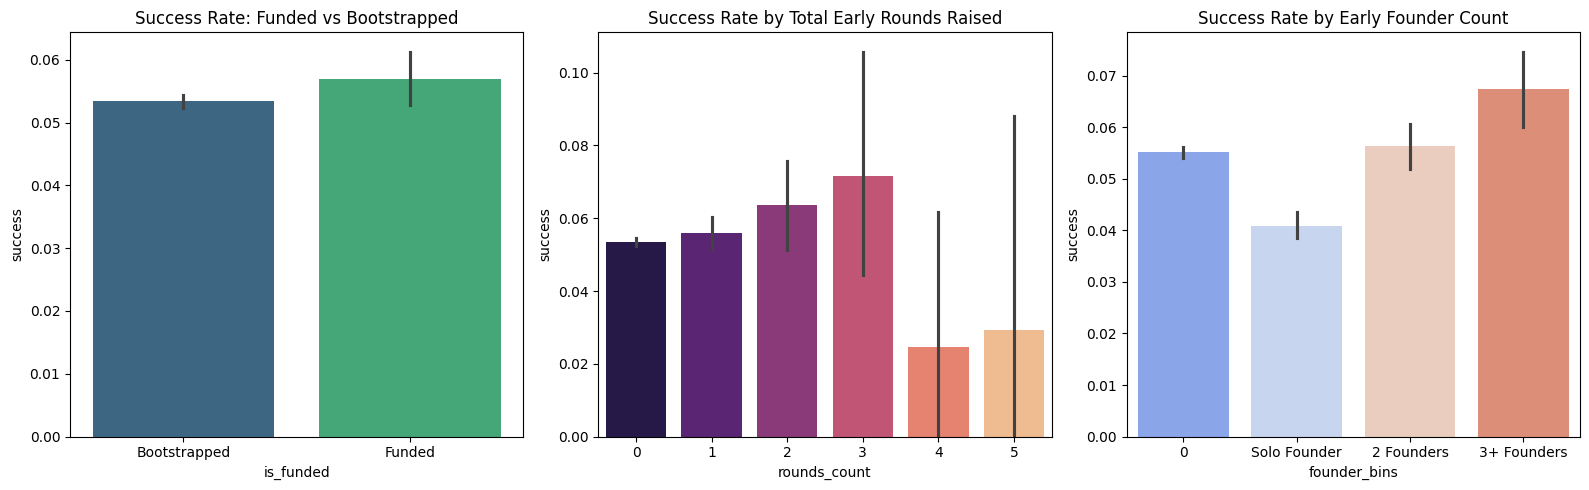


--- Companies with at least 2 funding rounds ---
Found 1888 companies that reached at least round 2.

                       name category_code country_code  success  pre_series_a_team_size  pre_series_a_founders  pre_series_a_clevel  pre_series_a_board  pre_series_a_vps  pre_series_a_employees  pre_series_a_milestones  pre_series_a_product_launches  pre_series_a_partnerships  pre_series_a_user_metrics  pre_series_a_awards  avg_founder_edu_score  has_top_uni_founder  founder_stem_ratio    round_1 duration_1 round_name_1    round_2 duration_2 round_name_2    round_3 duration_3 round_name_3 round_4 duration_4 round_name_4 round_5 duration_5 round_name_5
41                    Wevod   games_video          FRA        0                     2.0                    0.0                  1.0                 0.0               0.0                     1.0                      0.0                            0.0                        0.0                        0.0                  0.0               

In [ ]:
!pip install -q kagglehub
import pandas as pd
import numpy as np
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Download and Load Dataset
# ==========================================
print("Downloading dataset...")
path = kagglehub.dataset_download("justinas/startup-investments")

print("Loading CSV files...")
df_objects = pd.read_csv(os.path.join(path, "objects.csv"), low_memory=False)
df_rounds = pd.read_csv(os.path.join(path, "funding_rounds.csv"), low_memory=False)
df_relationships = pd.read_csv(os.path.join(path, "relationships.csv"), low_memory=False)
df_milestones = pd.read_csv(os.path.join(path, "milestones.csv"), low_memory=False)
df_degrees = pd.read_csv(os.path.join(path, "degrees.csv"), low_memory=False)
df_people = pd.read_csv(os.path.join(path, "people.csv"), low_memory=False)


# ==========================================
# 2. Base Companies & Target Variable
# ==========================================
print("Processing companies & demographics...")
df_companies = df_objects[df_objects['entity_type'] == 'Company'].copy()

df_companies = df_companies[['id', 'name', 'status', 'category_code', 'country_code', 'founded_at']]
df_companies['success'] = df_companies['status'].isin(['ipo', 'acquired']).astype(int)
df_companies['founded_at'] = pd.to_datetime(df_companies['founded_at'], errors='coerce')

# ==========================================
# 3. Filtering Logic & Cutoff Dates
# ==========================================
print("Establishing Series A cutoffs...")
df_rounds['funded_at'] = pd.to_datetime(df_rounds['funded_at'], errors='coerce')
df_rounds = df_rounds.dropna(subset=['funded_at'])

exclude_codes = ['debt_round', 'grant', 'post_ipo_debt', 'post_ipo_equity', 'secondary_market', 'partial']
df_rounds = df_rounds[~df_rounds['funding_round_code'].isin(exclude_codes)]

cutoff_codes = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'private_equity']
cutoff_types = ['series-a', 'series-b', 'series-c+', 'venture', 'private-equity', 'post-ipo']

is_series_a_or_later = (
    df_rounds['funding_round_code'].isin(cutoff_codes) |
    (df_rounds['funding_round_type'].isin(cutoff_types) & ~df_rounds['funding_round_code'].isin(['seed', 'angel']))
)

cutoff_dates = df_rounds[is_series_a_or_later].groupby('object_id')['funded_at'].min().reset_index()
cutoff_dates.rename(columns={'funded_at': 'cutoff_date'}, inplace=True)

df_companies = df_companies.merge(cutoff_dates, left_on='id', right_on='object_id', how='left').drop(columns=['object_id'])
df_rounds = df_rounds.merge(cutoff_dates, on='object_id', how='left')

valid_early_codes = ['seed', 'angel', 'convertible', 'crowd', 'crowd_equity']
valid_early_types = ['angel', 'crowdfunding']

early_rounds = df_rounds[
    (df_rounds['funded_at'] < df_rounds['cutoff_date']) |
    (df_rounds['cutoff_date'].isna() & (
        df_rounds['funding_round_code'].isin(valid_early_codes) |
        df_rounds['funding_round_type'].isin(valid_early_types)
    ))
].copy()

# ==========================================
# 4. Sequence & Durations
# ==========================================
early_rounds['raised_amount_usd'] = pd.to_numeric(early_rounds['raised_amount_usd'], errors='coerce')
early_rounds = early_rounds.sort_values(by=['object_id', 'funded_at'])
early_rounds['round_number'] = early_rounds.groupby('object_id').cumcount() + 1

MAX_ROUNDS = 5
early_rounds = early_rounds[early_rounds['round_number'] <= MAX_ROUNDS]

early_rounds = early_rounds.merge(df_companies[['id', 'founded_at']], left_on='object_id', right_on='id', how='left')
early_rounds['prev_funded_at'] = early_rounds.groupby('object_id')['funded_at'].shift(1)
early_rounds['reference_date'] = early_rounds['prev_funded_at'].fillna(early_rounds['founded_at'])

early_rounds['duration'] = (early_rounds['funded_at'] - early_rounds['reference_date']).dt.days
early_rounds['duration'] = early_rounds['duration'].clip(lower=0)

# ==========================================
# 5. Time-Box Relationships & Milestones
# ==========================================
print("Time-boxing and engineering features...")

df_relationships['created_at'] = pd.to_datetime(df_relationships['created_at'], errors='coerce')
rel_merged = df_relationships.merge(df_companies[['id', 'cutoff_date']], left_on='relationship_object_id', right_on='id', how='inner')

valid_rels = rel_merged[(rel_merged['created_at'] < rel_merged['cutoff_date']) | (rel_merged['cutoff_date'].isna())].copy()

valid_rels['title_lower'] = valid_rels['title'].str.lower().fillna('')

conditions = [
    valid_rels['title_lower'].str.contains('founder|founding', na=False),
    valid_rels['title_lower'].str.contains(r'\b(ceo|cto|coo|cfo|cio|cso|cmo|cro)\b|chief|president', regex=True, na=False),
    valid_rels['title_lower'].str.contains('board|advisor|investor|chairman|partner', na=False),
    valid_rels['title_lower'].str.contains(r'\b(vp|svp|evp)\b|vice president|director|head|manager', regex=True, na=False)
]

choices = ['founder', 'c_level', 'board_advisor', 'vp_director']
valid_rels['role_group'] = np.select(conditions, choices, default='employee')

role_dummies = pd.get_dummies(valid_rels['role_group'])

for col in choices + ['employee']:
    if col not in role_dummies.columns:
        role_dummies[col] = False

valid_rels = pd.concat([valid_rels, role_dummies], axis=1)

rel_features = valid_rels.groupby('relationship_object_id').agg(
    pre_series_a_team_size=('relationship_id', 'count'),
    pre_series_a_founders=('founder', 'sum'),
    pre_series_a_clevel=('c_level', 'sum'),
    pre_series_a_board=('board_advisor', 'sum'),
    pre_series_a_vps=('vp_director', 'sum'),
    pre_series_a_employees=('employee', 'sum')
).reset_index()

df_milestones['milestone_at'] = pd.to_datetime(df_milestones['milestone_at'], errors='coerce')
mil_merged = df_milestones.merge(df_companies[['id', 'cutoff_date']], left_on='object_id', right_on='id', how='inner')
valid_mils = mil_merged[(mil_merged['milestone_at'] < mil_merged['cutoff_date']) | (mil_merged['cutoff_date'].isna())].copy()

valid_mils['desc_lower'] = valid_mils['description'].str.lower().fillna('')

valid_mils['mil_product'] = valid_mils['desc_lower'].str.contains('launch|release|beta|prototype|version', regex=True).astype(int)
valid_mils['mil_partner'] = valid_mils['desc_lower'].str.contains('partner|teams up|agreement|integrate|deal', regex=True).astype(int)
valid_mils['mil_traction'] = valid_mils['desc_lower'].str.contains('users|members|downloads|million|customers|page views', regex=True).astype(int)
valid_mils['mil_award'] = valid_mils['desc_lower'].str.contains('award|winner|named|recognized|top', regex=True).astype(int)

mil_counts = valid_mils.groupby('object_id').agg(
    pre_series_a_milestones=('description', 'count'),
    pre_series_a_product_launches=('mil_product', 'sum'),
    pre_series_a_partnerships=('mil_partner', 'sum'),
    pre_series_a_user_metrics=('mil_traction', 'sum'),
    pre_series_a_awards=('mil_award', 'sum')
).reset_index()


# ==========================================
# >>> NEW SECTION ADDED: 5b. Degree Features
# ==========================================
print("Engineering education features...")

df_degrees['degree_type'] = df_degrees['degree_type'].fillna('Unknown')
df_degrees['institution'] = df_degrees['institution'].fillna('Unknown')
df_degrees['subject'] = df_degrees['subject'].fillna('Unknown')

def score_degree(degree_str):
    d = degree_str.lower()
    if 'phd' in d or 'ph.d' in d or 'doctor' in d: return 4
    if 'mba' in d: return 3
    if 'ms|' in d or d.startswith('ms') or 'master' in d: return 2
    if 'bs|' in d or d.startswith('bs') or 'bachelor' in d: return 1
    return 0

df_degrees['degree_score'] = df_degrees['degree_type'].apply(score_degree)
best_degree = df_degrees.groupby('object_id')['degree_score'].max().reset_index()
best_degree.rename(columns={'object_id': 'person_object_id', 'degree_score': 'best_degree_score'}, inplace=True)

TOP_UNIS = ['stanford', 'mit', 'harvard', 'berkeley', 'oxford', 'cambridge',
            'caltech', 'yale', 'princeton', 'columbia', 'wharton', 'insead']

def is_top_uni(inst_str):
    inst_lower = inst_str.lower()
    return int(any(u in inst_lower for u in TOP_UNIS))

top_uni = df_degrees.groupby('object_id')['institution'].apply(
    lambda x: int(x.apply(is_top_uni).max())
).reset_index()
top_uni.rename(columns={'object_id': 'person_object_id', 'institution': 'top_uni_flag'}, inplace=True)

STEM_KEYWORDS = ['computer', 'engineer', 'math', 'physics', 'science', 'software',
                 'data', 'electrical', 'biology', 'chemistry', 'information']

def is_stem(subj_str):
    s = subj_str.lower()
    return int(any(k in s for k in STEM_KEYWORDS))

stem_flag = df_degrees.groupby('object_id')['subject'].apply(
    lambda x: int(x.apply(is_stem).max())
).reset_index()
stem_flag.rename(columns={'object_id': 'person_object_id', 'subject': 'stem_flag'}, inplace=True)

people_edu = df_people[['object_id']].copy()
people_edu.rename(columns={'object_id': 'person_object_id'}, inplace=True)
people_edu = people_edu.merge(best_degree, on='person_object_id', how='left')
people_edu = people_edu.merge(top_uni, on='person_object_id', how='left')
people_edu = people_edu.merge(stem_flag, on='person_object_id', how='left')
people_edu[['best_degree_score', 'top_uni_flag', 'stem_flag']] = people_edu[['best_degree_score', 'top_uni_flag', 'stem_flag']].fillna(0)

founder_rels = valid_rels[valid_rels['role_group'] == 'founder'][['relationship_object_id', 'person_object_id']].copy()
founder_edu = founder_rels.merge(people_edu, on='person_object_id', how='left')

edu_features = founder_edu.groupby('relationship_object_id').agg(
    avg_founder_edu_score=('best_degree_score', 'mean'),
    has_top_uni_founder=('top_uni_flag', 'max'),
    founder_stem_ratio=('stem_flag', 'mean')
).reset_index()
# ==========================================
# <<< END OF NEW SECTION 5b
# ==========================================


# ==========================================
# 6. Pivot & Final Merge
# ==========================================
print("Building final dataset...")
early_rounds['clean_round_name'] = early_rounds['funding_round_code'].fillna(early_rounds['funding_round_type'])

pivot_df = early_rounds.pivot(
    index='object_id',
    columns='round_number',
    values=['raised_amount_usd', 'duration', 'clean_round_name']
)

new_cols = []
for col in pivot_df.columns:
    metric = "round" if col[0] == "raised_amount_usd" else "duration" if col[0] == "duration" else "round_name"
    new_cols.append(f"{metric}_{col[1]}")
pivot_df.columns = new_cols
pivot_df = pivot_df.reset_index()

final_df = df_companies[['id', 'name', 'category_code', 'country_code', 'success']].copy()
final_df = final_df.merge(pivot_df, left_on='id', right_on='object_id', how='left').drop(columns=['object_id'])
final_df = final_df.merge(rel_features, left_on='id', right_on='relationship_object_id', how='left').drop(columns=['relationship_object_id'], errors='ignore')
final_df = final_df.merge(mil_counts, left_on='id', right_on='object_id', how='left').drop(columns=['object_id'], errors='ignore')

# >>> NEW LINE ADDED: merge education features
final_df = final_df.merge(edu_features, left_on='id', right_on='relationship_object_id', how='left').drop(columns=['relationship_object_id'], errors='ignore')
# <<< END NEW LINE

feature_cols = [
    'pre_series_a_team_size', 'pre_series_a_founders', 'pre_series_a_clevel',
    'pre_series_a_board', 'pre_series_a_vps', 'pre_series_a_employees',
    'pre_series_a_milestones', 'pre_series_a_product_launches',
    'pre_series_a_partnerships', 'pre_series_a_user_metrics', 'pre_series_a_awards',
    # >>> NEW COLUMNS ADDED
    'avg_founder_edu_score', 'has_top_uni_founder', 'founder_stem_ratio'
    # <<< END NEW COLUMNS
]

# >>> CHANGED: split fillna logic by feature type
count_cols = [c for c in feature_cols if c not in ['avg_founder_edu_score', 'has_top_uni_founder', 'founder_stem_ratio']]
final_df[count_cols] = final_df[count_cols].fillna(0)
final_df[['avg_founder_edu_score', 'founder_stem_ratio']] = final_df[['avg_founder_edu_score', 'founder_stem_ratio']].fillna(final_df[['avg_founder_edu_score', 'founder_stem_ratio']].mean())
final_df['has_top_uni_founder'] = final_df['has_top_uni_founder'].fillna(0)
# <<< END CHANGE

ordered_cols = ['name', 'category_code', 'country_code', 'success'] + feature_cols
for i in range(1, MAX_ROUNDS + 1):
    for pref in ['round', 'duration', 'round_name']:
        col_name = f'{pref}_{i}'
        if col_name in final_df.columns:
            ordered_cols.append(col_name)

final_df = final_df[ordered_cols].reset_index(drop=True)

# ==========================================
# 7. Diagnostics & Plots
# ==========================================
final_df['is_funded'] = final_df['round_1'].notna().map({True: 'Funded', False: 'Bootstrapped'})

print(f"Total companies: {len(final_df)}")
print(f"Bootstrapped: {len(final_df[final_df['is_funded'] == 'Bootstrapped'])}")
print(f"Funded: {len(final_df[final_df['is_funded'] == 'Funded'])}")

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
sns.barplot(x='is_funded', y='success', data=final_df, palette='viridis')
plt.title('Success Rate: Funded vs Bootstrapped')

plt.subplot(1, 3, 2)
final_df['rounds_count'] = final_df[[f'round_{i}' for i in range(1, MAX_ROUNDS+1)]].notnull().sum(axis=1)
sns.barplot(x='rounds_count', y='success', data=final_df, palette='magma')
plt.title('Success Rate by Total Early Rounds Raised')

plt.subplot(1, 3, 3)
final_df['founder_bins'] = pd.cut(final_df['pre_series_a_founders'], bins=[-1, 0, 1, 2, 10], labels=['0', 'Solo Founder', '2 Founders', '3+ Founders'])
sns.barplot(x='founder_bins', y='success', data=final_df, palette='coolwarm')
plt.title('Success Rate by Early Founder Count')

plt.tight_layout()
plt.show()

final_df = final_df.drop(columns=['is_funded', 'rounds_count', 'founder_bins'])

# ==========================================
# 8. Filter & Print: Companies with >= 2 Rounds
# ==========================================
print("\n--- Companies with at least 2 funding rounds ---")

multi_round_companies = final_df[final_df['round_2'].notna()].copy()

print(f"Found {len(multi_round_companies)} companies that reached at least round 2.\n")

with pd.option_context('display.max_columns', None, 'display.width', 1000):
    print(multi_round_companies.head(10))

# Notes
After brainstorming about what is sucess we decided that all information about serie A-B-... doesn't matter. It's a great milestone for the startup but doesn't provide any money back to investor. Only criteria for sucess is aquired / IPO, nothing else.

note : important to not use serie A-B info for training because it's not data we have at seed stage. Eventually if time we can improve and try to predict for startup from stage serie A/B/C, to sucess but for now it's not our focus.

we might want to do a few different run, with different "time to fail" treshold meaning for example one with 3 years, meaing all startup founded less than 3 years ago don't count, and if after 3 years it's not aquired / IPO it's a failure. then we might want to do the same for 5 years

**data we will use in our prediction :**

* category_code,
* country_code,
* Human Capital = number of founder,
* time_to_first_funding from creation,
* a list of all the Degree type, 1 per human capital
* a list of Institution attended by participant, 1 per human capital separated by a special character predefined if some people attended multiple one.
* a list of Subject attended by participant, 1 per human capital separated by a special character predefined if some people attended multiple one.
* a list of "Graduate at"  attended by participant, 1 per human capital separated by a special character


In objects.csv
category_code
State_code
City

**potential one to also try :**

* founder_count = number of "founder" title in the team
,

next step : when define all inofrmation to use we try to create a table with with statup data, and also the infomation and then some "processed information", meaning from all team member education we create variable like "have 1 member of team a phd" "have they all the same academic title" "have they at all a master" ... and then latter when the ML algo will run with all thoses data he will tell us by sensitive analysis which one are more usefull.

Degree type
Institution
Subject
Graduate at ?

In objects.csv
category_code
State_code
City

# JEAN


In [ ]:
#THIS IS JEAN CELL
# 1. Install kagglehub (Required for Colab)
!pip install -q kagglehub

import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Download and load the dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("justinas/startup-investments")
objects_file = os.path.join(path, "objects.csv")

print("Loading data... (this might take a few seconds)")
df = pd.read_csv(objects_file, low_memory=False)

# print first line of data set
print("df.head()")
print(df.head())
print("df.shape")
print(df.shape)
print("df.columns")
print(df.columns)
print("df.info()")
print(df.info())
print("df.describe()")
print(df.describe())


Andy's version with Jean's add


In [ ]:
!pip install -q kagglehub
import pandas as pd
import numpy as np
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Download and Load Dataset
# ==========================================
print("Downloading dataset...")
path = kagglehub.dataset_download("justinas/startup-investments")

print("Loading CSV files...")
df_objects = pd.read_csv(os.path.join(path, "objects.csv"), low_memory=False)
df_rounds = pd.read_csv(os.path.join(path, "funding_rounds.csv"), low_memory=False)
df_relationships = pd.read_csv(os.path.join(path, "relationships.csv"), low_memory=False)
df_milestones = pd.read_csv(os.path.join(path, "milestones.csv"), low_memory=False)
df_degrees = pd.read_csv(os.path.join(path, "degrees.csv"), low_memory=False)
df_people = pd.read_csv(os.path.join(path, "people.csv"), low_memory=False)
df

# ==========================================
# 2. Base Companies & Target Variable
# ==========================================
print("Processing companies & demographics...")
df_companies = df_objects[df_objects['entity_type'] == 'Company'].copy()

# Keep demographics along with IDs and status
df_companies = df_companies[['id', 'name', 'status', 'category_code', 'country_code', 'founded_at']]
df_companies['success'] = df_companies['status'].isin(['ipo', 'acquired']).astype(int)
df_companies['founded_at'] = pd.to_datetime(df_companies['founded_at'], errors='coerce')

# ==========================================
# 3. Filtering Logic & Cutoff Dates
# ==========================================
print("Establishing Series A cutoffs...")
df_rounds['funded_at'] = pd.to_datetime(df_rounds['funded_at'], errors='coerce')
df_rounds = df_rounds.dropna(subset=['funded_at'])

exclude_codes = ['debt_round', 'grant', 'post_ipo_debt', 'post_ipo_equity', 'secondary_market', 'partial']
df_rounds = df_rounds[~df_rounds['funding_round_code'].isin(exclude_codes)]

# Cutoff logic for early rounds
cutoff_codes = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'private_equity']
cutoff_types = ['series-a', 'series-b', 'series-c+', 'venture', 'private-equity', 'post-ipo']

is_series_a_or_later = (
    df_rounds['funding_round_code'].isin(cutoff_codes) |
    (df_rounds['funding_round_type'].isin(cutoff_types) & ~df_rounds['funding_round_code'].isin(['seed', 'angel']))
)

cutoff_dates = df_rounds[is_series_a_or_later].groupby('object_id')['funded_at'].min().reset_index()
cutoff_dates.rename(columns={'funded_at': 'cutoff_date'}, inplace=True)

# Merge cutoff dates back to base companies to use for time-boxing
df_companies = df_companies.merge(cutoff_dates, left_on='id', right_on='object_id', how='left').drop(columns=['object_id'])
df_rounds = df_rounds.merge(cutoff_dates, on='object_id', how='left')

valid_early_codes = ['seed', 'angel', 'convertible', 'crowd', 'crowd_equity']
valid_early_types = ['angel', 'crowdfunding']

early_rounds = df_rounds[
    (df_rounds['funded_at'] < df_rounds['cutoff_date']) |
    (df_rounds['cutoff_date'].isna() & (
        df_rounds['funding_round_code'].isin(valid_early_codes) |
        df_rounds['funding_round_type'].isin(valid_early_types)
    ))
].copy()

# ==========================================
# 4. Sequence & Durations
# ==========================================
early_rounds['raised_amount_usd'] = pd.to_numeric(early_rounds['raised_amount_usd'], errors='coerce')
early_rounds = early_rounds.sort_values(by=['object_id', 'funded_at'])
early_rounds['round_number'] = early_rounds.groupby('object_id').cumcount() + 1

MAX_ROUNDS = 5
early_rounds = early_rounds[early_rounds['round_number'] <= MAX_ROUNDS]

early_rounds = early_rounds.merge(df_companies[['id', 'founded_at']], left_on='object_id', right_on='id', how='left')
early_rounds['prev_funded_at'] = early_rounds.groupby('object_id')['funded_at'].shift(1)
early_rounds['reference_date'] = early_rounds['prev_funded_at'].fillna(early_rounds['founded_at'])

early_rounds['duration'] = (early_rounds['funded_at'] - early_rounds['reference_date']).dt.days
early_rounds['duration'] = early_rounds['duration'].clip(lower=0)
# ==========================================
# 5. Time-Box Relationships & Milestones
# ==========================================
print("Time-boxing and engineering features...")

# --- Relationships Feature Engineering ---
df_relationships['created_at'] = pd.to_datetime(df_relationships['created_at'], errors='coerce')
rel_merged = df_relationships.merge(df_companies[['id', 'cutoff_date']], left_on='relationship_object_id', right_on='id', how='inner')

# Filter strictly to pre-Series A (or companies with no Series A)
valid_rels = rel_merged[(rel_merged['created_at'] < rel_merged['cutoff_date']) | (rel_merged['cutoff_date'].isna())].copy()

# Parse text to lowercase
valid_rels['title_lower'] = valid_rels['title'].str.lower().fillna('')

# Define mutually exclusive conditions using a hierarchy (Top to Bottom)
conditions = [
    valid_rels['title_lower'].str.contains('founder|founding', na=False),
    valid_rels['title_lower'].str.contains(r'\b(ceo|cto|coo|cfo|cio|cso|cmo|cro)\b|chief|president', regex=True, na=False),
    valid_rels['title_lower'].str.contains('board|advisor|investor|chairman|partner', na=False),
    valid_rels['title_lower'].str.contains(r'\b(vp|svp|evp)\b|vice president|director|head|manager', regex=True, na=False)
]

# Map conditions to their group names
choices = ['founder', 'c_level', 'board_advisor', 'vp_director']

# Apply the hierarchy (defaulting to 'employee' if no conditions match)
valid_rels['role_group'] = np.select(conditions, choices, default='employee')

# Create binary columns for the assigned groups
role_dummies = pd.get_dummies(valid_rels['role_group'])

# Ensure all expected columns exist (in case a sample lacks one of the roles)
for col in choices + ['employee']:
    if col not in role_dummies.columns:
        role_dummies[col] = False

# Join the binary columns back to the dataframe
valid_rels = pd.concat([valid_rels, role_dummies], axis=1)

# Aggregate into one row per company
rel_features = valid_rels.groupby('relationship_object_id').agg(
    pre_series_a_team_size=('relationship_id', 'count'),
    pre_series_a_founders=('founder', 'sum'),
    pre_series_a_clevel=('c_level', 'sum'),
    pre_series_a_board=('board_advisor', 'sum'),
    pre_series_a_vps=('vp_director', 'sum'),
    pre_series_a_employees=('employee', 'sum')
).reset_index()

# --- Milestones Time-Boxing & Feature Engineering ---
df_milestones['milestone_at'] = pd.to_datetime(df_milestones['milestone_at'], errors='coerce')
mil_merged = df_milestones.merge(df_companies[['id', 'cutoff_date']], left_on='object_id', right_on='id', how='inner')
valid_mils = mil_merged[(mil_merged['milestone_at'] < mil_merged['cutoff_date']) | (mil_merged['cutoff_date'].isna())].copy()

# Parse text to find key early events
valid_mils['desc_lower'] = valid_mils['description'].str.lower().fillna('')

# Create binary flags based on keywords
valid_mils['mil_product'] = valid_mils['desc_lower'].str.contains('launch|release|beta|prototype|version', regex=True).astype(int)
valid_mils['mil_partner'] = valid_mils['desc_lower'].str.contains('partner|teams up|agreement|integrate|deal', regex=True).astype(int)
valid_mils['mil_traction'] = valid_mils['desc_lower'].str.contains('users|members|downloads|million|customers|page views', regex=True).astype(int)
valid_mils['mil_award'] = valid_mils['desc_lower'].str.contains('award|winner|named|recognized|top', regex=True).astype(int)

# Aggregate into one row per company
mil_counts = valid_mils.groupby('object_id').agg(
    pre_series_a_milestones=('description', 'count'),
    pre_series_a_product_launches=('mil_product', 'sum'),
    pre_series_a_partnerships=('mil_partner', 'sum'),
    pre_series_a_user_metrics=('mil_traction', 'sum'),
    pre_series_a_awards=('mil_award', 'sum')
).reset_index()


# ==========================================
# 6. Pivot & Final Merge
# ==========================================
print("Building final dataset...")
early_rounds['clean_round_name'] = early_rounds['funding_round_code'].fillna(early_rounds['funding_round_type'])

pivot_df = early_rounds.pivot(
    index='object_id',
    columns='round_number',
    values=['raised_amount_usd', 'duration', 'clean_round_name']
)

# Flatten columns
new_cols = []
for col in pivot_df.columns:
    metric = "round" if col[0] == "raised_amount_usd" else "duration" if col[0] == "duration" else "round_name"
    new_cols.append(f"{metric}_{col[1]}")
pivot_df.columns = new_cols
pivot_df = pivot_df.reset_index()

# Left join keeps companies with 0 rounds
final_df = df_companies[['id', 'name', 'category_code', 'country_code', 'success']].copy()
final_df = final_df.merge(pivot_df, left_on='id', right_on='object_id', how='left').drop(columns=['object_id'])

# Merge Engineered Features (ID dropped safely later during column reordering)
final_df = final_df.merge(rel_features, left_on='id', right_on='relationship_object_id', how='left').drop(columns=['relationship_object_id'], errors='ignore')
final_df = final_df.merge(mil_counts, left_on='id', right_on='object_id', how='left').drop(columns=['object_id'], errors='ignore')

# Fill NaNs with 0 for companies that had no pre-Series A relationships/milestones
feature_cols = [
    'pre_series_a_team_size', 'pre_series_a_founders', 'pre_series_a_clevel',
    'pre_series_a_board', 'pre_series_a_vps', 'pre_series_a_employees',
    'pre_series_a_milestones', 'pre_series_a_product_launches',
    'pre_series_a_partnerships', 'pre_series_a_user_metrics', 'pre_series_a_awards'
]
final_df[feature_cols] = final_df[feature_cols].fillna(0)

# --- REORDER COLUMNS ---
ordered_cols = ['name', 'category_code', 'country_code', 'success'] + feature_cols
for i in range(1, MAX_ROUNDS + 1):
    for pref in ['round', 'duration', 'round_name']:
        col_name = f'{pref}_{i}'
        if col_name in final_df.columns:
            ordered_cols.append(col_name)

final_df = final_df[ordered_cols].reset_index(drop=True)

# ==========================================
# 7. Diagnostics & Plots
# ==========================================
final_df['is_funded'] = final_df['round_1'].notna().map({True: 'Funded', False: 'Bootstrapped'})

print(f"Total companies: {len(final_df)}")
print(f"Bootstrapped: {len(final_df[final_df['is_funded'] == 'Bootstrapped'])}")
print(f"Funded: {len(final_df[final_df['is_funded'] == 'Funded'])}")

plt.figure(figsize=(16, 5))

# Plot 1: Funded vs Bootstrapped
plt.subplot(1, 3, 1)
sns.barplot(x='is_funded', y='success', data=final_df, palette='viridis')
plt.title('Success Rate: Funded vs Bootstrapped')

# Plot 2: Total Early Rounds
plt.subplot(1, 3, 2)
final_df['rounds_count'] = final_df[[f'round_{i}' for i in range(1, MAX_ROUNDS+1)]].notnull().sum(axis=1)
sns.barplot(x='rounds_count', y='success', data=final_df, palette='magma')
plt.title('Success Rate by Total Early Rounds Raised')

# Plot 3: Success by Number of Founders
plt.subplot(1, 3, 3)
final_df['founder_bins'] = pd.cut(final_df['pre_series_a_founders'], bins=[-1, 0, 1, 2, 10], labels=['0', 'Solo Founder', '2 Founders', '3+ Founders'])
sns.barplot(x='founder_bins', y='success', data=final_df, palette='coolwarm')
plt.title('Success Rate by Early Founder Count')

plt.tight_layout()
plt.show()

# Clean up temporary plot bins
final_df = final_df.drop(columns=['is_funded', 'rounds_count', 'founder_bins'])


# ==========================================
# 8. Filter & Print: Companies with >= 2 Rounds
# ==========================================
print("\n--- Companies with at least 2 funding rounds ---")

# Filter where 'round_2' is not null
multi_round_companies = final_df[final_df['round_2'].notna()].copy()

print(f"Found {len(multi_round_companies)} companies that reached at least round 2.\n")

# Pandas truncates columns by default, so let's temporarily force it to show everything
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    # Print the first 10 rows to keep the console output clean
    print(multi_round_companies.head(10))

# New Section
3 field are missing
my last prompt wasn't clear here is a better version : in the table you gaved me there is almost all attribute requested except that I don't see the human capital (how many founder) neiteher the velocity, time from founding to seed round / last seed round but and the sucess / failure indicator, can you add those 3 attribute to the table and again print the 10 first entry with all the attribute ?

# Andi


##Only funding rounds, before series A

Using Colab cache for faster access to the 'startup-investments' dataset.
Processing companies...
Total companies: 196553
Bootstrapped: 184691
Funded: 11862


/tmp/ipykernel_1431/593750179.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='is_funded', y='success', data=final_df, palette='viridis')
/tmp/ipykernel_1431/593750179.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rounds_count', y='success', data=final_df, palette='magma')


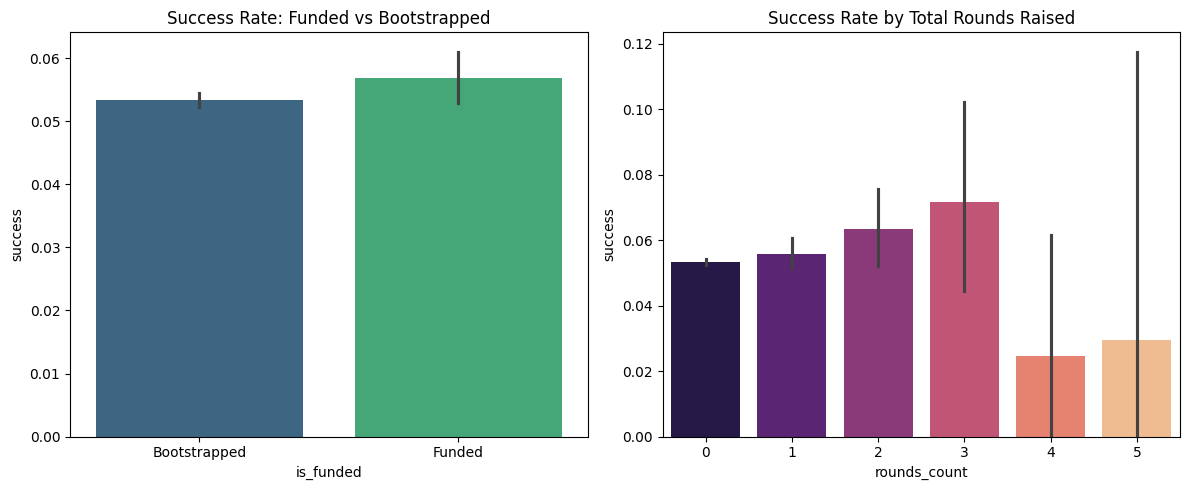

In [ ]:
!pip install -q kagglehub
import pandas as pd
import numpy as np
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Download and Load Dataset
# ==========================================
print("Downloading dataset...")
path = kagglehub.dataset_download("justinas/startup-investments")
df_objects = pd.read_csv(os.path.join(path, "objects.csv"), low_memory=False)
df_rounds = pd.read_csv(os.path.join(path, "funding_rounds.csv"), low_memory=False)

# ==========================================
# 2. Base Companies & Target Variable
# ==========================================
print("Processing companies...")
df_companies = df_objects[df_objects['entity_type'] == 'Company'].copy()
df_companies['success'] = df_companies['status'].isin(['ipo', 'acquired']).astype(int)
df_companies['founded_at'] = pd.to_datetime(df_companies['founded_at'], errors='coerce')

# ==========================================
# 3. Filtering Logic (Preserving Sequence)
# ==========================================
df_rounds['funded_at'] = pd.to_datetime(df_rounds['funded_at'], errors='coerce')
df_rounds = df_rounds.dropna(subset=['funded_at'])

exclude_codes = ['debt_round', 'grant', 'post_ipo_debt', 'post_ipo_equity', 'secondary_market', 'partial']
df_rounds = df_rounds[~df_rounds['funding_round_code'].isin(exclude_codes)]

# Cutoff logic for early rounds
cutoff_codes = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'private_equity']
cutoff_types = ['series-a', 'series-b', 'series-c+', 'venture', 'private-equity', 'post-ipo']

is_series_a_or_later = (
    df_rounds['funding_round_code'].isin(cutoff_codes) |
    (df_rounds['funding_round_type'].isin(cutoff_types) & ~df_rounds['funding_round_code'].isin(['seed', 'angel']))
)

cutoff_dates = df_rounds[is_series_a_or_later].groupby('object_id')['funded_at'].min().reset_index()
cutoff_dates.rename(columns={'funded_at': 'cutoff_date'}, inplace=True)
df_rounds = df_rounds.merge(cutoff_dates, on='object_id', how='left')

valid_early_codes = ['seed', 'angel', 'convertible', 'crowd', 'crowd_equity']
valid_early_types = ['angel', 'crowdfunding']

early_rounds = df_rounds[
    (df_rounds['funded_at'] < df_rounds['cutoff_date']) |
    (df_rounds['cutoff_date'].isna() & (
        df_rounds['funding_round_code'].isin(valid_early_codes) |
        df_rounds['funding_round_type'].isin(valid_early_types)
    ))
].copy()

# ==========================================
# 4. Sequence & Durations
# ==========================================
early_rounds['raised_amount_usd'] = pd.to_numeric(early_rounds['raised_amount_usd'], errors='coerce')
early_rounds = early_rounds.sort_values(by=['object_id', 'funded_at'])
early_rounds['round_number'] = early_rounds.groupby('object_id').cumcount() + 1

MAX_ROUNDS = 5
early_rounds = early_rounds[early_rounds['round_number'] <= MAX_ROUNDS]

early_rounds = early_rounds.merge(df_companies[['id', 'founded_at']], left_on='object_id', right_on='id', how='left')
early_rounds['prev_funded_at'] = early_rounds.groupby('object_id')['funded_at'].shift(1)
early_rounds['reference_date'] = early_rounds['prev_funded_at'].fillna(early_rounds['founded_at'])

early_rounds['duration'] = (early_rounds['funded_at'] - early_rounds['reference_date']).dt.days
early_rounds['duration'] = early_rounds['duration'].clip(lower=0)

# ==========================================
# 5. Pivot & Final Merge
# ==========================================
early_rounds['clean_round_name'] = early_rounds['funding_round_code'].fillna(early_rounds['funding_round_type'])

pivot_df = early_rounds.pivot(
    index='object_id',
    columns='round_number',
    values=['raised_amount_usd', 'duration', 'clean_round_name']
)

# Flatten columns
new_cols = []
for col in pivot_df.columns:
    metric = "round" if col[0] == "raised_amount_usd" else "duration" if col[0] == "duration" else "round_name"
    new_cols.append(f"{metric}_{col[1]}")
pivot_df.columns = new_cols
pivot_df = pivot_df.reset_index()

# THE IMPORTANT PART: Left join keeps companies with 0 rounds
final_df = df_companies[['id', 'name', 'success']].merge(pivot_df, left_on='id', right_on='object_id', how='left')

# --- REORDER COLUMNS (Fixed Syntax) ---
ordered_cols = ['name', 'success']
for i in range(1, MAX_ROUNDS + 1):
    for pref in ['round', 'duration', 'round_name']:
        col_name = f'{pref}_{i}'
        if col_name in final_df.columns:
            ordered_cols.append(col_name)

final_df = final_df[ordered_cols].reset_index(drop=True)

# ==========================================
# 6. Diagnostics & Plots
# ==========================================
final_df['is_funded'] = final_df['round_1'].notna().map({True: 'Funded', False: 'Bootstrapped'})

print(f"Total companies: {len(final_df)}")
print(f"Bootstrapped: {len(final_df[final_df['is_funded'] == 'Bootstrapped'])}")
print(f"Funded: {len(final_df[final_df['is_funded'] == 'Funded'])}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='is_funded', y='success', data=final_df, palette='viridis')
plt.title('Success Rate: Funded vs Bootstrapped')

plt.subplot(1, 2, 2)
final_df['rounds_count'] = final_df[[f'round_{i}' for i in range(1, MAX_ROUNDS+1)]].notnull().sum(axis=1)
sns.barplot(x='rounds_count', y='success', data=final_df, palette='magma')
plt.title('Success Rate by Total Rounds Raised')
plt.tight_layout()
plt.show()

##Enriched Country code, Relationships and milestones (not clustered)

Using Colab cache for faster access to the 'startup-investments' dataset.
Loading CSV files...
Processing companies & demographics...
Establishing Series A cutoffs...
Time-boxing and engineering features...


/tmp/ipykernel_1431/4286636037.py:103: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  valid_rels['title_lower'].str.contains(r'\b(ceo|cto|coo|cfo|cio|cso|cmo|cro)\b|chief|president', regex=True, na=False),
/tmp/ipykernel_1431/4286636037.py:105: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  valid_rels['title_lower'].str.contains(r'\b(vp|svp|evp)\b|vice president|director|head|manager', regex=True, na=False)


Building final dataset...
Total companies: 196553
Bootstrapped: 184691
Funded: 11862


/tmp/ipykernel_1431/4286636037.py:219: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='is_funded', y='success', data=final_df, palette='viridis')
/tmp/ipykernel_1431/4286636037.py:225: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rounds_count', y='success', data=final_df, palette='magma')
/tmp/ipykernel_1431/4286636037.py:231: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='founder_bins', y='success', data=final_df, palette='coolwarm')


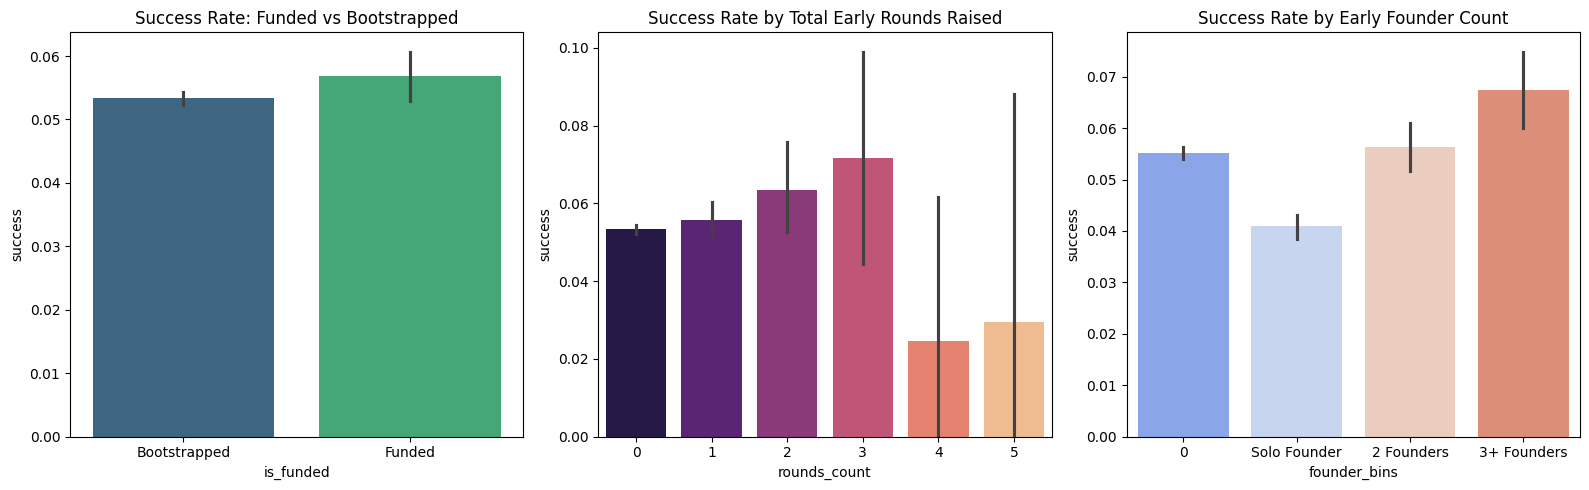


--- Companies with at least 2 funding rounds ---
Found 1790 companies that reached at least round 2.

                           name category_code country_code  success  pre_series_a_team_size  pre_series_a_founders  pre_series_a_clevel  pre_series_a_board  pre_series_a_vps  pre_series_a_employees  pre_series_a_milestones  pre_series_a_product_launches  pre_series_a_partnerships  pre_series_a_user_metrics  pre_series_a_awards    round_1 duration_1 round_name_1    round_2 duration_2 round_name_2 round_3 duration_3 round_name_3 round_4 duration_4 round_name_4 round_5 duration_5 round_name_5
18                      Mobclix        mobile          USA        1                     9.0                    1.0                  0.0                 2.0               0.0                     6.0                      1.0                            0.0                        0.0                        0.0                  0.0        0.0      184.0         seed        NaN        NaN          NaN    

In [ ]:
!pip install -q kagglehub
import pandas as pd
import numpy as np
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Download and Load Dataset
# ==========================================
print("Downloading dataset...")
path = kagglehub.dataset_download("justinas/startup-investments")

print("Loading CSV files...")
df_objects = pd.read_csv(os.path.join(path, "objects.csv"), low_memory=False)
df_rounds = pd.read_csv(os.path.join(path, "funding_rounds.csv"), low_memory=False)
df_relationships = pd.read_csv(os.path.join(path, "relationships.csv"), low_memory=False)
df_milestones = pd.read_csv(os.path.join(path, "milestones.csv"), low_memory=False)

# ==========================================
# 2. Base Companies & Target Variable
# ==========================================
print("Processing companies & demographics...")
df_companies = df_objects[df_objects['entity_type'] == 'Company'].copy()

# Keep demographics along with IDs and status
df_companies = df_companies[['id', 'name', 'status', 'category_code', 'country_code', 'founded_at']]
df_companies['success'] = df_companies['status'].isin(['ipo', 'acquired']).astype(int)
df_companies['founded_at'] = pd.to_datetime(df_companies['founded_at'], errors='coerce')

# ==========================================
# 3. Filtering Logic & Cutoff Dates
# ==========================================
print("Establishing Series A cutoffs...")
df_rounds['funded_at'] = pd.to_datetime(df_rounds['funded_at'], errors='coerce')
df_rounds = df_rounds.dropna(subset=['funded_at'])

exclude_codes = ['debt_round', 'grant', 'post_ipo_debt', 'post_ipo_equity', 'secondary_market', 'partial']
df_rounds = df_rounds[~df_rounds['funding_round_code'].isin(exclude_codes)]

# Cutoff logic for early rounds
cutoff_codes = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'private_equity']
cutoff_types = ['series-a', 'series-b', 'series-c+', 'venture', 'private-equity', 'post-ipo']

is_series_a_or_later = (
    df_rounds['funding_round_code'].isin(cutoff_codes) |
    (df_rounds['funding_round_type'].isin(cutoff_types) & ~df_rounds['funding_round_code'].isin(['seed', 'angel']))
)

cutoff_dates = df_rounds[is_series_a_or_later].groupby('object_id')['funded_at'].min().reset_index()
cutoff_dates.rename(columns={'funded_at': 'cutoff_date'}, inplace=True)

# Merge cutoff dates back to base companies to use for time-boxing
df_companies = df_companies.merge(cutoff_dates, left_on='id', right_on='object_id', how='left').drop(columns=['object_id'])
df_rounds = df_rounds.merge(cutoff_dates, on='object_id', how='left')

valid_early_codes = ['seed', 'angel', 'convertible', 'crowd', 'crowd_equity']
valid_early_types = ['angel', 'crowdfunding']

early_rounds = df_rounds[
    (df_rounds['funded_at'] < df_rounds['cutoff_date']) |
    (df_rounds['cutoff_date'].isna() & (
        df_rounds['funding_round_code'].isin(valid_early_codes) |
        df_rounds['funding_round_type'].isin(valid_early_types)
    ))
].copy()

# ==========================================
# 4. Sequence & Durations
# ==========================================
early_rounds['raised_amount_usd'] = pd.to_numeric(early_rounds['raised_amount_usd'], errors='coerce')
early_rounds = early_rounds.sort_values(by=['object_id', 'funded_at'])
early_rounds['round_number'] = early_rounds.groupby('object_id').cumcount() + 1

MAX_ROUNDS = 5
early_rounds = early_rounds[early_rounds['round_number'] <= MAX_ROUNDS]

early_rounds = early_rounds.merge(df_companies[['id', 'founded_at']], left_on='object_id', right_on='id', how='left')
early_rounds['prev_funded_at'] = early_rounds.groupby('object_id')['funded_at'].shift(1)
early_rounds['reference_date'] = early_rounds['prev_funded_at'].fillna(early_rounds['founded_at'])

early_rounds['duration'] = (early_rounds['funded_at'] - early_rounds['reference_date']).dt.days
early_rounds['duration'] = early_rounds['duration'].clip(lower=0)
# ==========================================
# 5. Time-Box Relationships & Milestones
# ==========================================
print("Time-boxing and engineering features...")

# --- Relationships Feature Engineering ---
df_relationships['created_at'] = pd.to_datetime(df_relationships['created_at'], errors='coerce')
rel_merged = df_relationships.merge(df_companies[['id', 'cutoff_date']], left_on='relationship_object_id', right_on='id', how='inner')

# Filter strictly to pre-Series A (or companies with no Series A)
valid_rels = rel_merged[(rel_merged['created_at'] < rel_merged['cutoff_date']) | (rel_merged['cutoff_date'].isna())].copy()

# Parse text to lowercase
valid_rels['title_lower'] = valid_rels['title'].str.lower().fillna('')

# Define mutually exclusive conditions using a hierarchy (Top to Bottom)
conditions = [
    valid_rels['title_lower'].str.contains('founder|founding', na=False),
    valid_rels['title_lower'].str.contains(r'\b(ceo|cto|coo|cfo|cio|cso|cmo|cro)\b|chief|president', regex=True, na=False),
    valid_rels['title_lower'].str.contains('board|advisor|investor|chairman|partner', na=False),
    valid_rels['title_lower'].str.contains(r'\b(vp|svp|evp)\b|vice president|director|head|manager', regex=True, na=False)
]

# Map conditions to their group names
choices = ['founder', 'c_level', 'board_advisor', 'vp_director']

# Apply the hierarchy (defaulting to 'employee' if no conditions match)
valid_rels['role_group'] = np.select(conditions, choices, default='employee')

# Create binary columns for the assigned groups
role_dummies = pd.get_dummies(valid_rels['role_group'])

# Ensure all expected columns exist (in case a sample lacks one of the roles)
for col in choices + ['employee']:
    if col not in role_dummies.columns:
        role_dummies[col] = False

# Join the binary columns back to the dataframe
valid_rels = pd.concat([valid_rels, role_dummies], axis=1)

# Aggregate into one row per company
rel_features = valid_rels.groupby('relationship_object_id').agg(
    pre_series_a_team_size=('relationship_id', 'count'),
    pre_series_a_founders=('founder', 'sum'),
    pre_series_a_clevel=('c_level', 'sum'),
    pre_series_a_board=('board_advisor', 'sum'),
    pre_series_a_vps=('vp_director', 'sum'),
    pre_series_a_employees=('employee', 'sum')
).reset_index()

# --- Milestones Time-Boxing & Feature Engineering ---
df_milestones['milestone_at'] = pd.to_datetime(df_milestones['milestone_at'], errors='coerce')
mil_merged = df_milestones.merge(df_companies[['id', 'cutoff_date']], left_on='object_id', right_on='id', how='inner')
valid_mils = mil_merged[(mil_merged['milestone_at'] < mil_merged['cutoff_date']) | (mil_merged['cutoff_date'].isna())].copy()

# Parse text to find key early events
valid_mils['desc_lower'] = valid_mils['description'].str.lower().fillna('')

# Create binary flags based on keywords
valid_mils['mil_product'] = valid_mils['desc_lower'].str.contains('launch|release|beta|prototype|version', regex=True).astype(int)
valid_mils['mil_partner'] = valid_mils['desc_lower'].str.contains('partner|teams up|agreement|integrate|deal', regex=True).astype(int)
valid_mils['mil_traction'] = valid_mils['desc_lower'].str.contains('users|members|downloads|million|customers|page views', regex=True).astype(int)
valid_mils['mil_award'] = valid_mils['desc_lower'].str.contains('award|winner|named|recognized|top', regex=True).astype(int)

# Aggregate into one row per company
mil_counts = valid_mils.groupby('object_id').agg(
    pre_series_a_milestones=('description', 'count'),
    pre_series_a_product_launches=('mil_product', 'sum'),
    pre_series_a_partnerships=('mil_partner', 'sum'),
    pre_series_a_user_metrics=('mil_traction', 'sum'),
    pre_series_a_awards=('mil_award', 'sum')
).reset_index()


# ==========================================
# 6. Pivot & Final Merge
# ==========================================
print("Building final dataset...")
early_rounds['clean_round_name'] = early_rounds['funding_round_code'].fillna(early_rounds['funding_round_type'])

pivot_df = early_rounds.pivot(
    index='object_id',
    columns='round_number',
    values=['raised_amount_usd', 'duration', 'clean_round_name']
)

# Flatten columns
new_cols = []
for col in pivot_df.columns:
    metric = "round" if col[0] == "raised_amount_usd" else "duration" if col[0] == "duration" else "round_name"
    new_cols.append(f"{metric}_{col[1]}")
pivot_df.columns = new_cols
pivot_df = pivot_df.reset_index()

# Left join keeps companies with 0 rounds
final_df = df_companies[['id', 'name', 'category_code', 'country_code', 'success']].copy()
final_df = final_df.merge(pivot_df, left_on='id', right_on='object_id', how='left').drop(columns=['object_id'])

# Merge Engineered Features (ID dropped safely later during column reordering)
final_df = final_df.merge(rel_features, left_on='id', right_on='relationship_object_id', how='left').drop(columns=['relationship_object_id'], errors='ignore')
final_df = final_df.merge(mil_counts, left_on='id', right_on='object_id', how='left').drop(columns=['object_id'], errors='ignore')

# Fill NaNs with 0 for companies that had no pre-Series A relationships/milestones
feature_cols = [
    'pre_series_a_team_size', 'pre_series_a_founders', 'pre_series_a_clevel',
    'pre_series_a_board', 'pre_series_a_vps', 'pre_series_a_employees',
    'pre_series_a_milestones', 'pre_series_a_product_launches',
    'pre_series_a_partnerships', 'pre_series_a_user_metrics', 'pre_series_a_awards'
]
final_df[feature_cols] = final_df[feature_cols].fillna(0)

# --- REORDER COLUMNS ---
ordered_cols = ['name', 'category_code', 'country_code', 'success'] + feature_cols
for i in range(1, MAX_ROUNDS + 1):
    for pref in ['round', 'duration', 'round_name']:
        col_name = f'{pref}_{i}'
        if col_name in final_df.columns:
            ordered_cols.append(col_name)

final_df = final_df[ordered_cols].reset_index(drop=True)

# ==========================================
# 7. Diagnostics & Plots
# ==========================================
final_df['is_funded'] = final_df['round_1'].notna().map({True: 'Funded', False: 'Bootstrapped'})

print(f"Total companies: {len(final_df)}")
print(f"Bootstrapped: {len(final_df[final_df['is_funded'] == 'Bootstrapped'])}")
print(f"Funded: {len(final_df[final_df['is_funded'] == 'Funded'])}")

plt.figure(figsize=(16, 5))

# Plot 1: Funded vs Bootstrapped
plt.subplot(1, 3, 1)
sns.barplot(x='is_funded', y='success', data=final_df, palette='viridis')
plt.title('Success Rate: Funded vs Bootstrapped')

# Plot 2: Total Early Rounds
plt.subplot(1, 3, 2)
final_df['rounds_count'] = final_df[[f'round_{i}' for i in range(1, MAX_ROUNDS+1)]].notnull().sum(axis=1)
sns.barplot(x='rounds_count', y='success', data=final_df, palette='magma')
plt.title('Success Rate by Total Early Rounds Raised')

# Plot 3: Success by Number of Founders
plt.subplot(1, 3, 3)
final_df['founder_bins'] = pd.cut(final_df['pre_series_a_founders'], bins=[-1, 0, 1, 2, 10], labels=['0', 'Solo Founder', '2 Founders', '3+ Founders'])
sns.barplot(x='founder_bins', y='success', data=final_df, palette='coolwarm')
plt.title('Success Rate by Early Founder Count')

plt.tight_layout()
plt.show()

# Clean up temporary plot bins
final_df = final_df.drop(columns=['is_funded', 'rounds_count', 'founder_bins'])


# ==========================================
# 8. Filter & Print: Companies with >= 2 Rounds
# ==========================================
print("\n--- Companies with at least 2 funding rounds ---")

# Filter where 'round_2' is not null
multi_round_companies = final_df[final_df['round_1'].notna()].copy()
multi_round_companies = multi_round_companies[multi_round_companies['pre_series_a_milestones'] > 0]

print(f"Found {len(multi_round_companies)} companies that reached at least round 2.\n")

# Pandas truncates columns by default, so let's temporarily force it to show everything
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    # Print the first 10 rows to keep the console output clean
    print(multi_round_companies.head(10))

##Milestones, but now clustered

In [ ]:
#This is the most advanced common cell (Cleaned up Data Loading)
!pip install -q kagglehub
import pandas as pd
import numpy as np
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Download and Load Dataset
# ==========================================
print("Downloading dataset...")
path = kagglehub.dataset_download("justinas/startup-investments")

print("Loading CSV files...")
df_objects = pd.read_csv(os.path.join(path, "objects.csv"), low_memory=False)
df_rounds = pd.read_csv(os.path.join(path, "funding_rounds.csv"), low_memory=False)
df_relationships = pd.read_csv(os.path.join(path, "relationships.csv"), low_memory=False)
df_degrees = pd.read_csv(os.path.join(path, "degrees.csv"), low_memory=False)
df_people = pd.read_csv(os.path.join(path, "people.csv"), low_memory=False)

# Load your custom AI clustered milestones right here at the start!
print("Loading AI Clustered Milestones from local file...")
df_milestones_custom = pd.read_csv('milestones_clustered.csv', low_memory=False)

# ==========================================
# 2. Base Companies & Target Variable
# ==========================================
print("Processing companies & demographics...")
df_companies = df_objects[df_objects['entity_type'] == 'Company'].copy()

df_companies = df_companies[['id', 'name', 'status', 'category_code', 'country_code', 'founded_at']]
df_companies['success'] = df_companies['status'].isin(['ipo', 'acquired']).astype(int)
df_companies['founded_at'] = pd.to_datetime(df_companies['founded_at'], errors='coerce')

# ==========================================
# 3. Filtering Logic & Cutoff Dates
# ==========================================
print("Establishing Series A cutoffs...")
df_rounds['funded_at'] = pd.to_datetime(df_rounds['funded_at'], errors='coerce')
df_rounds = df_rounds.dropna(subset=['funded_at'])

exclude_codes = ['debt_round', 'grant', 'post_ipo_debt', 'post_ipo_equity', 'secondary_market', 'partial']
df_rounds = df_rounds[~df_rounds['funding_round_code'].isin(exclude_codes)]

cutoff_codes = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'private_equity']
cutoff_types = ['series-a', 'series-b', 'series-c+', 'venture', 'private-equity', 'post-ipo']

is_series_a_or_later = (
    df_rounds['funding_round_code'].isin(cutoff_codes) |
    (df_rounds['funding_round_type'].isin(cutoff_types) & ~df_rounds['funding_round_code'].isin(['seed', 'angel']))
)

cutoff_dates = df_rounds[is_series_a_or_later].groupby('object_id')['funded_at'].min().reset_index()
cutoff_dates.rename(columns={'funded_at': 'cutoff_date'}, inplace=True)

df_companies = df_companies.merge(cutoff_dates, left_on='id', right_on='object_id', how='left').drop(columns=['object_id'])
df_rounds = df_rounds.merge(cutoff_dates, on='object_id', how='left')

valid_early_codes = ['seed', 'angel', 'convertible', 'crowd', 'crowd_equity']
valid_early_types = ['angel', 'crowdfunding']

early_rounds = df_rounds[
    (df_rounds['funded_at'] < df_rounds['cutoff_date']) |
    (df_rounds['cutoff_date'].isna() & (
        df_rounds['funding_round_code'].isin(valid_early_codes) |
        df_rounds['funding_round_type'].isin(valid_early_types)
    ))
].copy()

# ==========================================
# 4. Sequence & Durations
# ==========================================
early_rounds['raised_amount_usd'] = pd.to_numeric(early_rounds['raised_amount_usd'], errors='coerce')
early_rounds = early_rounds.sort_values(by=['object_id', 'funded_at'])
early_rounds['round_number'] = early_rounds.groupby('object_id').cumcount() + 1

MAX_ROUNDS = 5
early_rounds = early_rounds[early_rounds['round_number'] <= MAX_ROUNDS]

early_rounds = early_rounds.merge(df_companies[['id', 'founded_at']], left_on='object_id', right_on='id', how='left')
early_rounds['prev_funded_at'] = early_rounds.groupby('object_id')['funded_at'].shift(1)
early_rounds['reference_date'] = early_rounds['prev_funded_at'].fillna(early_rounds['founded_at'])

early_rounds['duration'] = (early_rounds['funded_at'] - early_rounds['reference_date']).dt.days
early_rounds['duration'] = early_rounds['duration'].clip(lower=0)

# ==========================================
# 5. Time-Box Relationships & Milestones
# ==========================================
print("Time-boxing and engineering features...")

# --- Relationships ---
df_relationships['created_at'] = pd.to_datetime(df_relationships['created_at'], errors='coerce')
rel_merged = df_relationships.merge(df_companies[['id', 'cutoff_date']], left_on='relationship_object_id', right_on='id', how='inner')
valid_rels = rel_merged[(rel_merged['created_at'] < rel_merged['cutoff_date']) | (rel_merged['cutoff_date'].isna())].copy()
valid_rels['title_lower'] = valid_rels['title'].str.lower().fillna('')

conditions = [
    valid_rels['title_lower'].str.contains('founder|founding', na=False),
    valid_rels['title_lower'].str.contains(r'\b(ceo|cto|coo|cfo|cio|cso|cmo|cro)\b|chief|president', regex=True, na=False),
    valid_rels['title_lower'].str.contains('board|advisor|investor|chairman|partner', na=False),
    valid_rels['title_lower'].str.contains(r'\b(vp|svp|evp)\b|vice president|director|head|manager', regex=True, na=False)
]

choices = ['founder', 'c_level', 'board_advisor', 'vp_director']
valid_rels['role_group'] = np.select(conditions, choices, default='employee')

role_dummies = pd.get_dummies(valid_rels['role_group'])
for col in choices + ['employee']:
    if col not in role_dummies.columns:
        role_dummies[col] = False

valid_rels = pd.concat([valid_rels, role_dummies], axis=1)

rel_features = valid_rels.groupby('relationship_object_id').agg(
    pre_series_a_team_size=('relationship_id', 'count'),
    pre_series_a_founders=('founder', 'sum'),
    pre_series_a_clevel=('c_level', 'sum'),
    pre_series_a_board=('board_advisor', 'sum'),
    pre_series_a_vps=('vp_director', 'sum'),
    pre_series_a_employees=('employee', 'sum')
).reset_index()

# --- AI Clustered Milestones ---
# We already loaded df_milestones_custom in Section 1, so we just process it here!
df_milestones_custom['milestone_at'] = pd.to_datetime(df_milestones_custom['milestone_at'], errors='coerce')

mil_merged = df_milestones_custom.merge(df_companies[['id', 'cutoff_date']], left_on='object_id', right_on='id', how='inner')
valid_mils = mil_merged[(mil_merged['milestone_at'] < mil_merged['cutoff_date']) | (mil_merged['cutoff_date'].isna())].copy()

# Create dummy columns for the 8 cluster labels
expected_clusters = [
    'app_mobile_iphone', 'com_new_million', 'launched_launch_beta',
    'acquired_acquires_com', 'ceo_founder_founded', 'million_funding_round',
    'award_awards_wins', 'invested_capital_investment'
]
mil_dummies = pd.get_dummies(valid_mils['cluster_label'], prefix='milestone')

# Guarantee all 8 columns exist even if filtering removed some
for cluster in expected_clusters:
    col_name = f'milestone_{cluster}'
    if col_name not in mil_dummies.columns:
        mil_dummies[col_name] = False

valid_mils = pd.concat([valid_mils, mil_dummies], axis=1)

mil_cols_to_sum = [f'milestone_{c}' for c in expected_clusters]
agg_dict = {col: 'sum' for col in mil_cols_to_sum}
agg_dict['description'] = 'count' # Keep total milestone count

mil_counts = valid_mils.groupby('object_id').agg(agg_dict).reset_index()
mil_counts.rename(columns={'description': 'pre_series_a_total_milestones'}, inplace=True)

# ==========================================
# 5b. Degree Features
# ==========================================
print("Engineering education features...")

df_degrees['degree_type'] = df_degrees['degree_type'].fillna('Unknown')
df_degrees['institution'] = df_degrees['institution'].fillna('Unknown')
df_degrees['subject'] = df_degrees['subject'].fillna('Unknown')

def score_degree(degree_str):
    d = degree_str.lower()
    if 'phd' in d or 'ph.d' in d or 'doctor' in d: return 4
    if 'mba' in d: return 3
    if 'ms' in d or d.startswith('ms') or 'master' in d: return 2
    if 'bs' in d or d.startswith('bs') or 'bachelor' in d: return 1
    return 0

df_degrees['degree_score'] = df_degrees['degree_type'].apply(score_degree)
best_degree = df_degrees.groupby('object_id')['degree_score'].max().reset_index()
best_degree.rename(columns={'object_id': 'person_object_id', 'degree_score': 'best_degree_score'}, inplace=True)

TOP_UNIS = ['eth','stanford', 'mit', 'harvard', 'berkeley', 'oxford', 'cambridge',
            'caltech', 'yale', 'princeton', 'columbia', 'wharton', 'insead']

def is_top_uni(inst_str):
    inst_lower = inst_str.lower()
    return int(any(u in inst_lower for u in TOP_UNIS))

top_uni = df_degrees.groupby('object_id')['institution'].apply(
    lambda x: int(x.apply(is_top_uni).max())
).reset_index()
top_uni.rename(columns={'object_id': 'person_object_id', 'institution': 'top_uni_flag'}, inplace=True)

STEM_KEYWORDS = ['computer', 'engineer', 'math', 'physics', 'science', 'software',
                 'data', 'electrical', 'biology', 'chemistry', 'information']

def is_stem(subj_str):
    s = subj_str.lower()
    return int(any(k in s for k in STEM_KEYWORDS))

stem_flag = df_degrees.groupby('object_id')['subject'].apply(
    lambda x: int(x.apply(is_stem).max())
).reset_index()
stem_flag.rename(columns={'object_id': 'person_object_id', 'subject': 'stem_flag'}, inplace=True)

people_edu = df_people[['object_id']].copy()
people_edu.rename(columns={'object_id': 'person_object_id'}, inplace=True)
people_edu = people_edu.merge(best_degree, on='person_object_id', how='left')
people_edu = people_edu.merge(top_uni, on='person_object_id', how='left')
people_edu = people_edu.merge(stem_flag, on='person_object_id', how='left')
people_edu[['best_degree_score', 'top_uni_flag', 'stem_flag']] = people_edu[['best_degree_score', 'top_uni_flag', 'stem_flag']].fillna(0)

founder_rels = valid_rels[valid_rels['role_group'] == 'founder'][['relationship_object_id', 'person_object_id']].copy()
founder_edu = founder_rels.merge(people_edu, on='person_object_id', how='left')

edu_features = founder_edu.groupby('relationship_object_id').agg(
    avg_founder_edu_score=('best_degree_score', 'mean'),
    has_top_uni_founder=('top_uni_flag', 'max'),
    founder_stem_ratio=('stem_flag', 'mean')
).reset_index()

# ==========================================
# 6. Pivot & Final Merge
# ==========================================
print("Building final dataset...")
early_rounds['clean_round_name'] = early_rounds['funding_round_code'].fillna(early_rounds['funding_round_type'])

pivot_df = early_rounds.pivot(
    index='object_id',
    columns='round_number',
    values=['raised_amount_usd', 'duration', 'clean_round_name']
)

new_cols = []
for col in pivot_df.columns:
    metric = "round" if col[0] == "raised_amount_usd" else "duration" if col[0] == "duration" else "round_name"
    new_cols.append(f"{metric}_{col[1]}")
pivot_df.columns = new_cols
pivot_df = pivot_df.reset_index()

final_df = df_companies[['id', 'name', 'category_code', 'country_code', 'success']].copy()
final_df = final_df.merge(pivot_df, left_on='id', right_on='object_id', how='left').drop(columns=['object_id'])
final_df = final_df.merge(rel_features, left_on='id', right_on='relationship_object_id', how='left').drop(columns=['relationship_object_id'], errors='ignore')
final_df = final_df.merge(mil_counts, left_on='id', right_on='object_id', how='left').drop(columns=['object_id'], errors='ignore')
final_df = final_df.merge(edu_features, left_on='id', right_on='relationship_object_id', how='left').drop(columns=['relationship_object_id'], errors='ignore')

# Update feature cols to look for the AI Clusters
feature_cols = [
    'pre_series_a_team_size', 'pre_series_a_founders', 'pre_series_a_clevel',
    'pre_series_a_board', 'pre_series_a_vps', 'pre_series_a_employees',
    'avg_founder_edu_score', 'has_top_uni_founder', 'founder_stem_ratio',
    'pre_series_a_total_milestones',
    'milestone_app_mobile_iphone', 'milestone_com_new_million', 'milestone_launched_launch_beta',
    'milestone_acquired_acquires_com', 'milestone_ceo_founder_founded', 'milestone_million_funding_round',
    'milestone_award_awards_wins', 'milestone_invested_capital_investment'
]
final_df[feature_cols] = final_df[feature_cols].fillna(0)

ordered_cols = ['name', 'category_code', 'country_code', 'success'] + feature_cols
for i in range(1, MAX_ROUNDS + 1):
    for pref in ['round', 'duration', 'round_name']:
        col_name = f'{pref}_{i}'
        if col_name in final_df.columns:
            ordered_cols.append(col_name)

final_df = final_df[ordered_cols].reset_index(drop=True)

# ==========================================
# 7. Diagnostics & Plots
# ==========================================
final_df['is_funded'] = final_df['round_1'].notna().map({True: 'Funded', False: 'Bootstrapped'})

print(f"Total companies: {len(final_df)}")
print(f"Bootstrapped: {len(final_df[final_df['is_funded'] == 'Bootstrapped'])}")
print(f"Funded: {len(final_df[final_df['is_funded'] == 'Funded'])}")

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
sns.barplot(x='is_funded', y='success', data=final_df, palette='viridis')
plt.title('Success Rate: Funded vs Bootstrapped')

plt.subplot(1, 3, 2)
final_df['rounds_count'] = final_df[[f'round_{i}' for i in range(1, MAX_ROUNDS+1)]].notnull().sum(axis=1)
sns.barplot(x='rounds_count', y='success', data=final_df, palette='magma')
plt.title('Success Rate by Total Early Rounds Raised')

plt.subplot(1, 3, 3)
final_df['founder_bins'] = pd.cut(final_df['pre_series_a_founders'], bins=[-1, 0, 1, 2, 10], labels=['0', 'Solo Founder', '2 Founders', '3+ Founders'])
sns.barplot(x='founder_bins', y='success', data=final_df, palette='coolwarm')
plt.title('Success Rate by Early Founder Count')

plt.tight_layout()
plt.show()

final_df = final_df.drop(columns=['is_funded', 'rounds_count', 'founder_bins'])

# ==========================================
# 8. Filter & Print: Companies with >= 2 Rounds
# ==========================================
print("\n--- Companies with at least 2 funding rounds ---")

multi_round_companies = final_df[final_df['round_2'].notna()].copy()

print(f"Found {len(multi_round_companies)} companies that reached at least round 2.\n")

with pd.option_context('display.max_columns', None, 'display.width', 1000):
    print(multi_round_companies.head(10))

Using Colab cache for faster access to the 'startup-investments' dataset.
Loading CSV files...
Loading AI Clustered Milestones from local file...


FileNotFoundError: [Errno 2] No such file or directory: 'milestones_clustered.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Clustering of Milestones

In [ ]:
# Install the necessary NLP and clustering libraries
!pip install -q kagglehub sentence-transformers scikit-learn pandas

import pandas as pd
import numpy as np
import kagglehub
import os
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from google.colab import files

print("1. Downloading dataset...")
path = kagglehub.dataset_download("justinas/startup-investments")
df_milestones = pd.read_csv(os.path.join(path, "milestones.csv"), low_memory=False)

# Drop rows where description is completely missing
df_milestones = df_milestones.dropna(subset=['description']).copy()
print(f"Loaded {len(df_milestones)} milestones.")

print("\n2. Generating Embeddings (This takes ~15 seconds on a GPU, or a few minutes on CPU)...")
# Load the lightweight, state-of-the-art embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Convert the text descriptions into 384-dimensional mathematical vectors
embeddings = model.encode(df_milestones['description'].tolist(), show_progress_bar=True)

print("\n3. Clustering the embeddings using K-Means (k=8)...")
num_clusters = 8
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df_milestones['cluster_id'] = kmeans.fit_predict(embeddings)

print("\n4. Automatically assigning labels using TF-IDF Keyword Extraction...")
# This function finds the most representative words for each cluster
def get_cluster_labels(df, text_col, cluster_col, n_terms=3):
    labels = {}
    for c in sorted(df[cluster_col].unique()):
        texts = df[df[cluster_col] == c][text_col].dropna()
        # Extract top words, ignoring standard stop words like "the", "and", "is"
        vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
        try:
            tfidf_matrix = vectorizer.fit_transform(texts)
            scores = tfidf_matrix.sum(axis=0).A1
            words = vectorizer.get_feature_names_out()
            # Get the indices of the highest scoring words
            top_indices = scores.argsort()[::-1][:n_terms]
            top_words = [words[i] for i in top_indices]
            # Join them with an underscore
            labels[c] = "_".join(top_words)
        except Exception:
            labels[c] = f"cluster_{c}"
    return labels

# Generate and apply the labels
cluster_mapping = get_cluster_labels(df_milestones, 'description', 'cluster_id', n_terms=3)
df_milestones['cluster_label'] = df_milestones['cluster_id'].map(cluster_mapping)

print("\n--- Here are your automatically generated cluster labels! ---")
for cluster_num, label_name in cluster_mapping.items():
    print(f"Cluster {cluster_num}: {label_name}")

print("\n5. Saving to CSV and downloading...")
# Keep only what we need to save space
output_df = df_milestones[['id', 'object_id', 'milestone_at', 'description', 'cluster_label']]
output_file = 'milestones_clustered.csv'
output_df.to_csv(output_file, index=False)

# Trigger the download to your local machine!
files.download(output_file)
print("Download triggered! You can now use this file in your main algorithm.")

1. Downloading dataset...
Using Colab cache for faster access to the 'startup-investments' dataset.
Loaded 39456 milestones.

2. Generating Embeddings (This takes ~15 seconds on a GPU, or a few minutes on CPU)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Batches:   0%|          | 0/1233 [00:00<?, ?it/s]


3. Clustering the embeddings using K-Means (k=8)...

4. Automatically assigning labels using TF-IDF Keyword Extraction...

--- Here are your automatically generated cluster labels! ---
Cluster 0: million_funding_round
Cluster 1: acquired_acquires_com
Cluster 2: app_mobile_iphone
Cluster 3: ceo_founder_founded
Cluster 4: award_awards_wins
Cluster 5: invested_capital_investment
Cluster 6: launched_launch_beta
Cluster 7: com_new_million

5. Saving to CSV and downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered! You can now use this file in your main algorithm.
